# Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor

!pip install catboost
from catboost import CatBoostRegressor

!pip install optuna
import optuna
!pip install optuna-integration
from optuna.integration import LightGBMPruningCallback

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 3.2 MB/s eta 0:00:00


# Functions

In [2]:
# data/load.py
def load_rideshare_data(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

# Cleaning

In [3]:
df = load_rideshare_data("rideshare_feature_engineering.csv")

In [4]:
df.shape

(637976, 49)

In [5]:
df.head()

,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,...,log_distance,surge_x_distance,surge_intensity,is_surge,tier_enc,cab_type_enc,route_frequency,name_enc,destination_enc,source_enc
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,1.0,...,0.364643,0.44,0.0,0,0,1,8874,7,7,5
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,1.0,...,0.364643,0.44,0.0,0,2,1,8874,2,7,5
2,1,28,11,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,1.0,...,0.364643,0.44,0.0,0,1,1,8874,5,7,5
3,4,30,11,Haymarket Square,North Station,Lyft,Lux Black XL,26.0,0.44,1.0,...,0.364643,0.44,0.0,0,2,1,8874,4,7,5
4,3,29,11,Haymarket Square,North Station,Lyft,Lyft XL,9.0,0.44,1.0,...,0.364643,0.44,0.0,0,1,1,8874,6,7,5


In [6]:
df.isnull().sum()

,0
hour,0
day,0
month,0
source,0
destination,0
cab_type,0
name,0
price,0
distance,0
surge_multiplier,0


In [7]:
df.columns

Index(['hour', 'day', 'month', 'source', 'destination', 'cab_type', 'name',
       'price', 'distance', 'surge_multiplier', 'latitude', 'longitude',
       'temperature', 'apparentTemperature', 'short_summary',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'visibility', 'temperatureHigh', 'temperatureLow',
       'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint',
       'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone',
       'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax',
       'apparentTemperatureMin', 'apparentTemperatureMax', 'tier', 'route',
       'log_distance', 'surge_x_distance', 'surge_intensity', 'is_surge',
       'tier_enc', 'cab_type_enc', 'route_frequency', 'name_enc',
       'destination_enc', 'source_enc'],
      dtype='object')

In [8]:
df.select_dtypes(include=["object"]).columns

Index(['source', 'destination', 'cab_type', 'name', 'short_summary', 'tier',
       'route'],
      dtype='object')

In [9]:
# From EDA. name, src-dest pair, are good

string_cols = ['source', 'destination', 'cab_type',
               'name', 'short_summary', 'tier', 'route']

uncorrelated_cols = [
    "latitude", "moonPhase", "visibility", "longitude",
    "windBearing", "humidity", "windGust", "precipIntensityMax",
    "windSpeed", "cloudCover", "pressure", "apparentTemperatureLow",
    "dewPoint", "apparentTemperatureMin", "temperatureMax", "temperatureHigh",
    "ozone", "temperatureMin", "uvIndex", "apparentTemperatureMax",
    "apparentTemperatureHigh", "precipProbability", "apparentTemperature", "temperatureLow",
    "precipIntensity","temperature", "hour", "day",
    "month"
]

transformed_cols = ["distance"]

data_leakage_cols = ["route_frequency"]

df = df.drop(columns=string_cols + uncorrelated_cols + transformed_cols + data_leakage_cols)

In [10]:
df.columns

Index(['price', 'surge_multiplier', 'log_distance', 'surge_x_distance',
       'surge_intensity', 'is_surge', 'tier_enc', 'cab_type_enc', 'name_enc',
       'destination_enc', 'source_enc'],
      dtype='object')

# Split Data

In [11]:
X = df.drop(columns="price")
y = df["price"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Compare Models

In [12]:
model_configs = [
    {
        "name": "LinearRegression",
        "model": LinearRegression(),
        "params": {}
    },
    {
        "name": "Ridge",
        "model": Ridge(),
        "params": {
            "alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
        }
    },
    {
        "name": "Lasso",
        "model": Lasso(max_iter=5000),
        "params": {
            "alpha": [0.001, 0.01, 0.1, 1.0]
        }
    },
    {
        "name": "ElasticNet",
        "model": ElasticNet(max_iter=5000),
        "params": {
            "alpha": [0.001, 0.01, 0.1],
            "l1_ratio": [0.2, 0.5, 0.8]
        }
    },
    {
        "name": "HistGradientBoosting",
        "model": HistGradientBoostingRegressor(random_state=42),
        "params": {
            "max_iter": [100, 300],
            "learning_rate": [0.05, 0.1],
            "max_depth": [6, 10],
            "min_samples_leaf": [20, 50]
        }
    },
    {
        "name": "ExtraTrees",
        "model": ExtraTreesRegressor(n_jobs=-1),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [10, 20],
            "min_samples_split": [2, 5]
        }
    },
    {
        "name": "XGBoost",
        "model": XGBRegressor(n_jobs=-1, verbosity=0),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [3, 6],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0]
        }
    },
    {
        "name": "LightGBM",
        "model": LGBMRegressor(n_jobs=-1),
        "params": {
            "n_estimators": [100, 300],
            "num_leaves": [31, 64],
            "learning_rate": [0.05, 0.1]
        }
    },
    {
        "name": "CatBoost",
        "model": CatBoostRegressor(verbose=0),
        "params": {
            "iterations": [100, 300],
            "depth": [4, 6],
            "learning_rate": [0.05, 0.1]
        }
    }
]

In [13]:
# CV strategy
cv = KFold(n_splits=3, shuffle=True, random_state=42)

results = []

print("\n=== MODEL COMPARISON (CV RMSE) ===")
print(f"{'Model':<15} {'RMSE':<12} {'Std':<10} {'Best Params'}")

for cfg in model_configs:
    start_time = time.time()
    name = cfg["name"]
    model = clone(cfg["model"])

    # Case 1: No hyperparameters → simple CV
    if not cfg["params"]:
        scores = cross_val_score(
            model,
            X_train_full,
            y_train_full,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1
        )

        rmse = -scores.mean()
        std = scores.std()
        best_params = "N/A"

    # Case 2: Has hyperparameters → RandomizedSearchCV
    else:
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=cfg["params"],
            n_iter=5,  # coarse search
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
            random_state=42,
            verbose=1
        )

        search.fit(X_train_full, y_train_full)

        rmse = -search.best_score_
        std = None  # not directly available from search
        best_params = search.best_params_

    elapsed = time.time() - start_time

    results.append({
        "Model": name,
        "RMSE": rmse,
        "Std": std,
        "BestParams": best_params,
        "TimeSec": elapsed
    })

    print(f"{name:<15} {rmse:<12.4f} {str(std):<10} {best_params}")

# Final dataframe
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print("\n=== SORTED RESULTS ===")
print(results_df)


=== MODEL COMPARISON (CV RMSE) ===
Model           RMSE         Std        Best Params
LinearRegression 5.0855       0.010678770604261258 N/A
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Ridge           5.0855       None       {'alpha': 1.0}
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Lasso           5.0856       None       {'alpha': 0.001}
Fitting 3 folds for each of 5 candidates, totalling 15 fits
ElasticNet      5.0858       None       {'l1_ratio': 0.5, 'alpha': 0.001}
Fitting 3 folds for each of 5 candidates, totalling 15 fits
HistGradientBoosting 1.6522       None       {'min_samples_leaf': 20, 'max_iter': 300, 'max_depth': 10, 'learning_rate': 0.1}
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


ExtraTrees      1.6462       None       {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 20}
Fitting 3 folds for each of 5 candidates, totalling 15 fits
XGBoost         1.6469       None       {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.091836 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 815
[LightGBM] [Info] Number of data points in the train set: 510380, number of used features: 10
[LightGBM] [Info] Start training from score 16.545838
LightGBM        1.6275       None       {'num_leaves': 64, 'n_estimators': 300, 'learning_rate': 0.1}
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CatBoost        1.6966       None       {'learning_rate': 0.1, 'iterations': 300, 'depth': 6}

=== SORTED RESULTS ===
                  Model      RMSE       Std  \
0              LightGBM  1.627536       NaN   
1            ExtraTrees  1.646229       NaN   
2               XGBoost  1.646922       NaN   
3  HistGradientBoosting  1.652206       NaN   
4              CatBoost  1.696577       NaN   
5                 Ridge  5.085498       NaN   
6      LinearRegression  5.085498  0.010679   
7                 Lasso  5.085553       NaN   
8            ElasticNet  5.085798       NaN   

                                          BestParams      TimeSec  
0  {'num_leaves': 64, 'n_estimators': 300, 'learn...   240.591802  
1  {'n_estimators': 300, 'min_samples_split': 5, ...  1883.525786  
2  {'subsample': 0.8, 'n_estimators': 300, 'max_d...    78.496449  
3  {'min_samples_leaf': 20, 'max_iter': 300, 'max...   100.206130  
4  {'learning_rate': 0.1, 'iterations': 300, 'dep...   179.528894  
5  

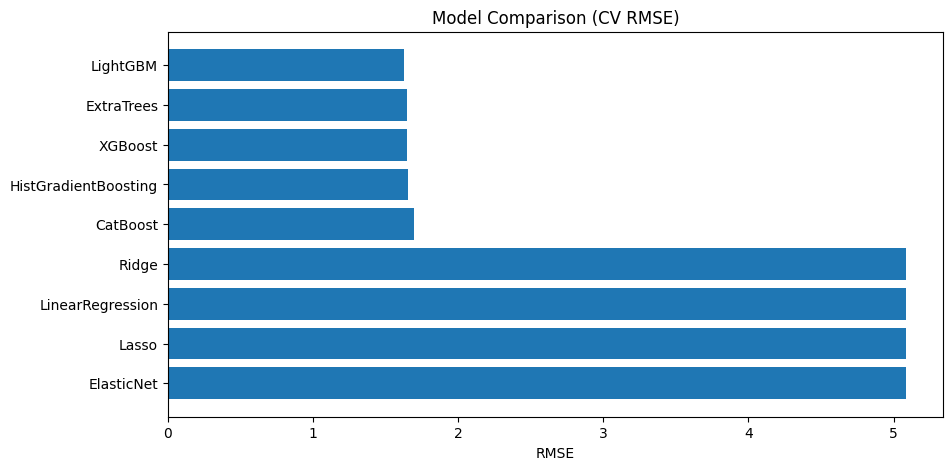

In [14]:
plt.figure(figsize=(10, 5))

plt.barh(results_df["Model"], results_df["RMSE"])

plt.xlabel("RMSE")
plt.title("Model Comparison (CV RMSE)")
plt.gca().invert_yaxis()

plt.show()

# Tune the best model

In [15]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42
)

In [16]:
def objective(trial):
    params = {
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 32, 128),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "max_bin": trial.suggest_int("max_bin", 128, 255),
        "random_state": 42,
        "n_jobs": -1
    }

    model = LGBMRegressor(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            LightGBMPruningCallback(trial, "rmse")
        ]
    )

    trial.set_user_attr("best_iteration", model.best_iteration_)

    preds = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    return rmse

In [17]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, timeout=1200)

[I 2026-04-24 05:18:42,707] A new study created in memory with name: no-name-50815c11-ceb0-48f6-be10-e0b66a997522


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 555
[LightGBM] [Info] Number of data points in the train set: 408304, number of used features: 10
[LightGBM] [Info] Start training from score 16.549402
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-04-24 05:22:45,090] Trial 0 finished with value: 1.6178210707343608 and parameters: {'learning_rate': 0.06989116218587428, 'num_leaves': 42, 'max_depth': 8, 'min_child_samples': 75, 'subsample': 0.8566356614082236, 'colsample_bytree': 0.9717017682166673, 'reg_alpha': 0.0021805431646374496, 'reg_lambda': 0.024451921946364436, 'max_bin': 168}. Best is trial 0 with value: 1.6178210707343608.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 759
[LightGBM] [Info] Number of data points in the train set: 408304, number of used features: 10
[LightGBM] [Info] Start training from score 16.549402
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-04-24 05:24:55,106] Trial 1 finished with value: 1.6106144061055334 and parameters: {'learning_rate': 0.066212835351794, 'num_leaves': 127, 'max_depth': 9, 'min_child_samples': 26, 'subsample': 0.7866741781714616, 'colsample_bytree': 0.7439356266436488, 'reg_alpha': 0.18954411370789748, 'reg_lambda': 0.06484734699600866, 'max_bin': 236}. Best is trial 1 with value: 1.6106144061055334.


...

[I 2026-04-24 05:33:19,988] Trial 3 finished with value: 1.633902126641142 and parameters: {'learning_rate': 0.02176787356186324, 'num_leaves': 89, 'max_depth': 6, 'min_child_samples': 109, 'subsample': 0.7636151779619813, 'colsample_bytree': 0.9399591608763338, 'reg_alpha': 0.006689697342413912, 'reg_lambda': 0.662661977590126, 'max_bin': 183}. Best is trial 1 with value: 1.6106144061055334.


Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-04-24 05:37:02,417] Trial 4 finished with value: 1.6219324821736378 and parameters: {'learning_rate': 0.07503208529069108, 'num_leaves': 123, 'max_depth': 6, 'min_child_samples': 105, 'subsample': 0.9069302960599279, 'colsample_bytree': 0.9210684559266894, 'reg_alpha': 0.40370905102798227, 'reg_lambda': 0.694532740499737, 'max_bin': 215}. Best is trial 1 with value: 1.6106144061055334.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 579
[LightGBM] [Info] Number of data points in the train set: 408304, number of used features: 10
[LightGBM] [Info] Start training from score 16.549402
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-04-24 05:41:27,146] Trial 5 finished with value: 1.6174006592930967 and parameters: {'learning_rate': 0.08077879034584014, 'num_leaves': 83, 'max_depth': 7, 'min_child_samples': 90, 'subsample': 0.8133482072707642, 'colsample_bytree': 0.825276319698762, 'reg_alpha': 0.413009797589453, 'reg_lambda': 0.4425229499818657, 'max_bin': 176}. Best is trial 1 with value: 1.6106144061055334.


In [18]:
print("Best RMSE:", study.best_value)
print("Best Params:", study.best_params)

Best RMSE: 1.6106144061055334
Best Params: {'learning_rate': 0.066212835351794, 'num_leaves': 127, 'max_depth': 9, 'min_child_samples': 26, 'subsample': 0.7866741781714616, 'colsample_bytree': 0.7439356266436488, 'reg_alpha': 0.18954411370789748, 'reg_lambda': 0.06484734699600866, 'max_bin': 236}


# Train Final Model


In [19]:
best_model = LGBMRegressor(
    **study.best_params,
    n_estimators=study.best_trial.user_attrs.get("best_iteration", 5000),
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_full, y_train_full)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064448 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 758
[LightGBM] [Info] Number of data points in the train set: 510380, number of used features: 10
[LightGBM] [Info] Start training from score 16.545838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMRegressor(colsample_bytree=0.7439356266436488,
              learning_rate=0.066212835351794, max_bin=236, max_depth=9,
              min_child_samples=26, n_estimators=2302, n_jobs=-1,
              num_leaves=127, random_state=42, reg_alpha=0.18954411370789748,
              reg_lambda=0.06484734699600866, subsample=0.7866741781714616)

In [20]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Evaluation on Test Set")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Final Evaluation on Test Set
RMSE: 1.5952
R2 Score: 0.9708


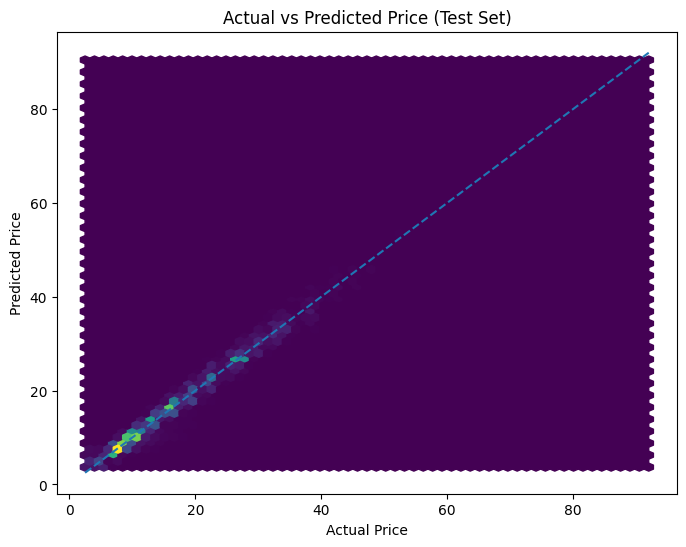

In [21]:
plt.figure(figsize=(8, 6))
plt.hexbin(y_test, y_pred, gridsize=60)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Test Set)")

plt.show()